<head>
    <style>
        .md-typeset h2 {
            margin:0;
            }
        .md-typeset h3 {
            margin:0;
            }
        .jupyter-wrapper table.dataframe tr, .jupyter-wrapper table.dataframe th, .jupyter-wrapper table.dataframe td {
            text-align:left;
            }
        .jupyter-wrapper table.dataframe {
            table-layout: auto;
            }
    </style>        
</head>

# Customize Your Jupyter Notebook with Mkdocs Material

## Introduction 

If you are using `Jupyter Notebook` plugin developed by 
[Daniel Rodriguez](https://github.com/danielfrg/mkdocs-jupyter), you might notice
that the `cell` of Jupyter Notebook is not rendered well. You could visit
his [demo-site](https://mkdocs-jupyter.danielfrg.com/demo-nb/) to check the
rendering. 

Still, thanks to him, we could use `Jupyter Notebook` with `Mkdocs Material`.
In this post, I will share what I did to twist the rendering of the `cell` and
make it to become expandable and collapsible.

__This post was written in Jupyter Notebook__, which shows the customized style. 

## Hide `In` and `Out` prefix

To hide `In` and `Out` prefix of the `cell`, you could add the following code
into your `extra.css`. 

In [ ]:
.jp-CodeCell > .jp-Cell-inputWrapper {
    direction: rtl;
    width:113%;
}

.jp-InputArea-prompt {
    visibility: hidden;
} 

.jp-OutputArea-prompt {
    visibility: hidden;  /* disable this to tune the position */
    background-color:red; 
    position:absolute;
    right: 0;
    
}

.jp-CodeCell > .jp-Cell-outputWrapper {
    margin-top: -10px;
    padding-top:0;
    display: table-cell;
    text-align: left;
}
.jp-Cell-outputWrapper > .jp-Cell-outputCollapser {
    /* background-color:red; */
    margin-top: -17px;
}


## Add expand and collapse button

When the `code` becomes very long, readers might get distracted. Therefore,
I would like to hide my code and make the post more readable. This ideas was 
inspired by the blog written by [Peter Roelants](https://peterroelants.github.io/posts/about-this-blog/).
He enables custom features like the cell collapse buttons in `Jekyll` environment
and `Jupyter Notebook`. 

Although the collapsed code still makes the post look a series of connected `blocks`,
it does make sense when one block is telling the same story. For instance, in
this section, we will focus on building a button to expand and collapse the
code block. One should focus on the story (reading those words) rather than
jump on a bunch of `code`. Therefore, I think hiding the code is better. 

* First, you need add the following `CSS` code into your `extra.css`.

In [ ]:
/* Jupyter code block expand and collapse*/
.expandClass {
    border: 1.5px solid #7D838A;
    color: #7D838A;
    border-radius: 3px;
    padding-left:2px;
    padding-right:2px;
    margin-right:3px;
    }
.active, .expandClass:hover{
    background: #7D838A;
    color:white;
}
.jupyter-wrapper  .highlight-ipynb {
    display:none;
}
.zeroclipboard-container {
    position: relative !important;
    float:right;
}


* Second, you need to create an `JavaScript` file (I call it `code_expand_collapse.js`)
and copy the following code into this file. 

In [ ]:
document.body.onload = call_fun;
function inputExpandCollapse() {
    let copy_button = document.querySelectorAll(".expandClass");
    for (let i = 0; i < copy_button.length; i++) {
        copy_button[i].addEventListener("click", function() {
            this.classList.toggle("active");
            var content = document.getElementsByClassName("highlight-ipynb");
            var elem2 = document.getElementsByClassName("zeroclipboard-container");
            if (content[i].style.display === "block") {
                content[i].style.display = "none";
                elem2[i].style.setProperty('position', 'relative', 'important');
                } else {
                    content[i].style.display = "block";
                    elem2[i].style.setProperty('position', 'absolute', 'important');
                }
            });
    }
}
function insertNew() {
    // create new elements
    var button = document.createElement("button");
    button.innerHTML = "+";
    button.setAttribute("class", "expandClass");
    // append another one 
    const elem2 = document.getElementsByClassName("zeroclipboard-container");
    for (let i = 0; i < elem2.length; i++) {
        elem2[i].appendChild(button.cloneNode(true));
    }
    // insert new id
    var code_div = document.getElementsByClassName("highlight-ipynb");
    for (let i = 0; i < code_div.length; i++) {
        code_div[i].setAttribute("id", "code-cell"+"-"+i.toString());
    }
    // select clipboard-copy element
    var clipboard_button = document.querySelectorAll("clipboard-copy");
    for (let i = 0; i < clipboard_button.length; i++) {
        clipboard_button[i].setAttribute("for", "code-cell"+"-"+i.toString());
    }
}
function call_fun() {
    insertNew();
    inputExpandCollapse();
}

After all those work, your post should like this one too. By the way, the 
`code` in the above block also fix the bug of `clipboard-copy`. The original 
`copy` button does preserve the indent whenever you copy. It is not user-friendly,
therefore I fix it too. 

## Table alignment

This one is a minor issue. The default table cell is aligned right. It does not 
look good. I change it to make it align left. 

In [1]:
import seaborn as sns 
sns.set_style('darkgrid')
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Here is the `css` code to do it. 

In [ ]:
.jupyter-wrapper table.dataframe tr, .jupyter-wrapper table.dataframe th, .jupyter-wrapper table.dataframe td {
    text-align:left;
}
.jupyter-wrapper table.dataframe {
    table-layout: auto;
}

## Do a plot 

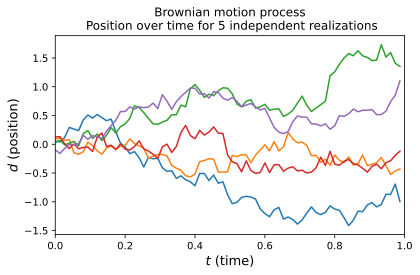

In [2]:
# Import essential packages
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set matplotlib and seaborn plotting style
np.random.seed(42)

# 1D simulation of the Brownian motion process
total_time = 1
nb_steps = 75
delta_t = total_time / nb_steps
nb_processes = 5  # Simulate 5 different motions
mean = 0.  # Mean of each movement
stdev = np.sqrt(delta_t)  # Standard deviation of each movement

# Simulate the brownian motions in a 1D space by cumulatively
#  making a new movement delta_d
distances = np.cumsum(
    # Move randomly from current location to N(0, delta_t)
    np.random.normal(
        mean, stdev, (nb_processes, nb_steps)),
    axis=1)

plt.figure(figsize=(6, 4))
# Make the plots
t = np.arange(0, total_time, delta_t)
for i in range(nb_processes):
    plt.plot(t, distances[i,:])
plt.title((
    'Brownian motion process\n '
    'Position over time for 5 independent realizations'))
plt.xlabel('$t$ (time)', fontsize=13)
plt.ylabel('$d$ (position)', fontsize=13)
plt.xlim([-0, 1])
plt.tight_layout()
plt.show()

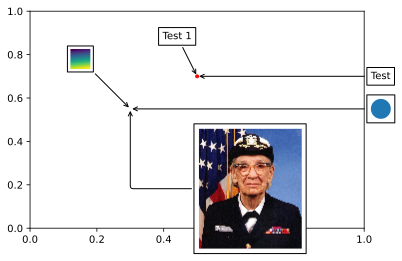

In [4]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Circle
from matplotlib.offsetbox import (TextArea, DrawingArea, OffsetImage,
                                  AnnotationBbox)
from matplotlib.cbook import get_sample_data


fig, ax = plt.subplots()

# Define a 1st position to annotate (display it with a marker)
xy = (0.5, 0.7)
ax.plot(xy[0], xy[1], ".r")

# Annotate the 1st position with a text box ('Test 1')
offsetbox = TextArea("Test 1")

ab = AnnotationBbox(offsetbox, xy,
                    xybox=(-20, 40),
                    xycoords='data',
                    boxcoords="offset points",
                    arrowprops=dict(arrowstyle="->"))
ax.add_artist(ab)

# Annotate the 1st position with another text box ('Test')
offsetbox = TextArea("Test")

ab = AnnotationBbox(offsetbox, xy,
                    xybox=(1.02, xy[1]),
                    xycoords='data',
                    boxcoords=("axes fraction", "data"),
                    box_alignment=(0., 0.5),
                    arrowprops=dict(arrowstyle="->"))
ax.add_artist(ab)

# Define a 2nd position to annotate (don't display with a marker this time)
xy = [0.3, 0.55]

# Annotate the 2nd position with a circle patch
da = DrawingArea(20, 20, 0, 0)
p = Circle((10, 10), 10)
da.add_artist(p)

ab = AnnotationBbox(da, xy,
                    xybox=(1.02, xy[1]),
                    xycoords='data',
                    boxcoords=("axes fraction", "data"),
                    box_alignment=(0., 0.5),
                    arrowprops=dict(arrowstyle="->"))

ax.add_artist(ab)

# Annotate the 2nd position with an image (a generated array of pixels)
arr = np.arange(100).reshape((10, 10))
im = OffsetImage(arr, zoom=2)
im.image.axes = ax

ab = AnnotationBbox(im, xy,
                    xybox=(-50., 50.),
                    xycoords='data',
                    boxcoords="offset points",
                    pad=0.3,
                    arrowprops=dict(arrowstyle="->"))

ax.add_artist(ab)

# Annotate the 2nd position with another image (a Grace Hopper portrait)
with get_sample_data("grace_hopper.jpg") as file:
    arr_img = plt.imread(file)

imagebox = OffsetImage(arr_img, zoom=0.2)
imagebox.image.axes = ax

ab = AnnotationBbox(imagebox, xy,
                    xybox=(120., -80.),
                    xycoords='data',
                    boxcoords="offset points",
                    pad=0.5,
                    arrowprops=dict(
                        arrowstyle="->",
                        connectionstyle="angle,angleA=0,angleB=90,rad=3")
                    )

ax.add_artist(ab)

# Fix the display limits to see everything
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()

In [8]:
import seaborn as sns 
sns.set_style('darkgrid')
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


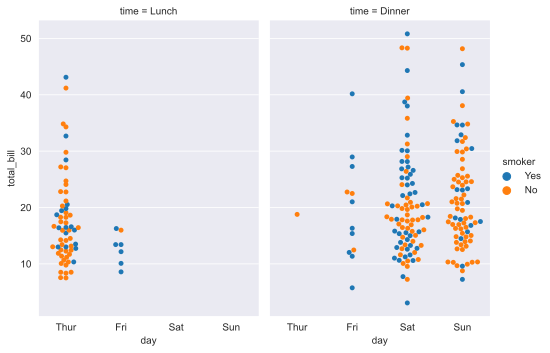

In [7]:
sns.set_style('darkgrid')
tips = sns.load_dataset("tips")
sns.catplot(x="day", y="total_bill", hue="smoker",
            col="time", aspect=.7,
            kind="swarm", data=tips)